# 03 - Entrenamiento y Evaluacion

En este notebook se entrenan y comparan modelos supervisados para predecir si una reserva hotelera sera cancelada.

El dataset limpio mantiene duplicados exactos porque no existe un identificador unico de reserva (`booking_id`) que permita confirmar que sean errores. Para comprobar el impacto de esta decision, se comparan dos versiones creadas en memoria:

1. **Con duplicados:** version principal del proyecto.
2. **Sin duplicados:** version experimental creada con `drop_duplicates()`.

La comparacion con y sin duplicados se realiza en memoria. El split final del proyecto se guarda aparte en `data/train/train.csv` y `data/test/test.csv`.


## 0. Importacion de librerias y configuracion

In [34]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "is_canceled"

PROCESSED_PATH = Path("..") / "data" / "processed" / "hotel_bookings_clean.csv"
MODELS_DIR = Path("..") / "models"

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)


## 1. Carga del dataset limpio y creacion de versiones

Cargo el dataset limpio generado en `02_LimpiezaEDA.ipynb`. A partir de este dataset creo dos versiones en memoria: una mantiene duplicados y otra elimina filas exactamente repetidas.

In [35]:
df_clean = pd.read_csv(PROCESSED_PATH)

versions = {
    "with_duplicates": df_clean.copy(),
    "no_duplicates": df_clean.drop_duplicates().reset_index(drop=True),
}

summary = []
for name, data in versions.items():
    summary.append({
        "version": name,
        "filas": data.shape[0],
        "columnas": data.shape[1],
        "duplicados_exactos": data.duplicated().sum(),
        "cancelaciones_%": round(data[TARGET].mean() * 100, 2),
    })

pd.DataFrame(summary)


,version,filas,columnas,duplicados_exactos,cancelaciones_%
0,with_duplicates,118564,34,33191,37.26
1,no_duplicates,85373,34,0,27.75


## 2. Preprocesado comun

Se aplica el mismo preprocesado a todos los modelos y a las dos versiones del dataset:

- Variables numericas: imputacion con mediana.
- Variables categoricas: imputacion con moda + One-Hot Encoding.
- Escalado: se aplica para que Regresion Logistica funcione correctamente y para mantener un preprocesado comun entre modelos.

In [36]:
def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])


## 3. Modelos supervisados

Se comparan cinco modelos supervisados:

1. Regresion Logistica: modelo base interpretable.
2. Decision Tree: modelo de reglas sencillo.
3. Random Forest: ensemble robusto basado en muchos arboles.
4. Gradient Boosting: boosting clasico de `sklearn`.
5. XGBoost: boosting avanzado, muy competitivo en datos tabulares.

XGBoost se incluye porque suele funcionar muy bien en problemas tabulares de clasificacion con relaciones no lineales e interacciones entre variables.


In [37]:
def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
        ),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

## 4. Modelo no supervisado: KMeans (Clustering)

Ademas de los modelos supervisados, incluyo un modelo no supervisado para cumplir el requisito del proyecto y explorar segmentos de reservas similares.

KMeans no predice directamente `is_canceled`; agrupa reservas segun variables numericas relevantes. Despues se revisa la tasa media de cancelacion por cluster para interpretar si algunos segmentos tienen mayor riesgo.


In [38]:
cluster_data = versions["with_duplicates"].copy()
cluster_features = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "previous_cancellations",
    "booking_changes",
    "total_of_special_requests",
]

cluster_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init="auto")),
])

cluster_data["cluster"] = cluster_pipe.fit_predict(cluster_data[cluster_features])
cluster_summary = cluster_data.groupby("cluster")[cluster_features + [TARGET]].mean().round(2)
cluster_summary


,lead_time,adr,total_nights,total_guests,previous_cancellations,booking_changes,total_of_special_requests,is_canceled
cluster,,,,,,,,
0,120.47,86.80,2.56,1.73,0.16,0.10,0.03,0.49
1,65.56,99.37,2.98,1.92,0.02,0.11,1.44,0.20
2,81.64,183.77,3.78,3.06,0.00,0.26,0.74,0.39
3,152.13,90.87,7.45,1.94,0.03,0.87,0.52,0.30


## 5. Funcion de evaluacion

In [39]:
def evaluate_model(version_name, model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Comprueba si el modelo puede devolver probabilidades
    if hasattr(model, "predict_proba"):  
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = np.nan

    return {
        "version": version_name,
        "modelo": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc,
    }, model

## 6. Entrenamiento comparativo

Para cada version del dataset se hace un `train_test_split` estratificado y se entrenan los mismos modelos. Esto permite comprobar si eliminar duplicados cambia las metricas.

In [40]:
results = []
trained_models = {}
splits = {}

for version_name, data in versions.items():
    X = data.drop(columns=[TARGET])
    y = data[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    splits[version_name] = (X_train, X_test, y_train, y_test)

    for model_name, classifier in get_models().items():
        # Cada modelo necesita su propio preprocesador.
        # Si se reutiliza el mismo, se puede reajustar con otro dataset y romper predicciones posteriores.
        pipe = Pipeline(steps=[
            ("preprocessor", build_preprocessor(X_train)),
            ("model", classifier),
        ])

        result, fitted_model = evaluate_model(
            version_name,
            model_name,
            pipe,
            X_train,
            X_test,
            y_train,
            y_test,
        )
        results.append(result)
        trained_models[(version_name, model_name)] = fitted_model

results_df = pd.DataFrame(results).sort_values(["f1", "roc_auc"], ascending=False)
results_df.round(4)


,version,modelo,accuracy,precision,recall,f1,roc_auc
4,with_duplicates,XGBoost,0.8565,0.8399,0.7595,0.7977,0.9338
2,with_duplicates,Random Forest,0.8452,0.8157,0.7553,0.7843,0.9232
3,with_duplicates,Gradient Boosting,0.8421,0.8306,0.7237,0.7735,0.9190
1,with_duplicates,Decision Tree,0.7980,0.6789,0.8690,0.7623,0.9072
0,with_duplicates,Logistic Regression,0.8099,0.7324,0.7718,0.7516,0.8954
9,no_duplicates,XGBoost,0.8327,0.7397,0.6129,0.6704,0.8958
6,no_duplicates,Decision Tree,0.7618,0.5463,0.8358,0.6607,0.8668
7,no_duplicates,Random Forest,0.7529,0.5341,0.8565,0.6579,0.8742
5,no_duplicates,Logistic Regression,0.7575,0.5443,0.7756,0.6397,0.8480
8,no_duplicates,Gradient Boosting,0.8200,0.7343,0.5507,0.6294,0.8792


## 7. Comparacion visual de metricas

Visualizo las metricas principales para comparar rapidamente el comportamiento de los modelos con y sin duplicados. El primer grafico usa `f1` como metrica resumen porque equilibra precision y recall.


Uso F1 en el siguiente gráfico como métrica principal porque el problema requiere equilibrar la detección de cancelaciones reales con la precisión de las alertas generadas. No obstante, también reviso accuracy, precision, recall y ROC-AUC para una evaluación completa.

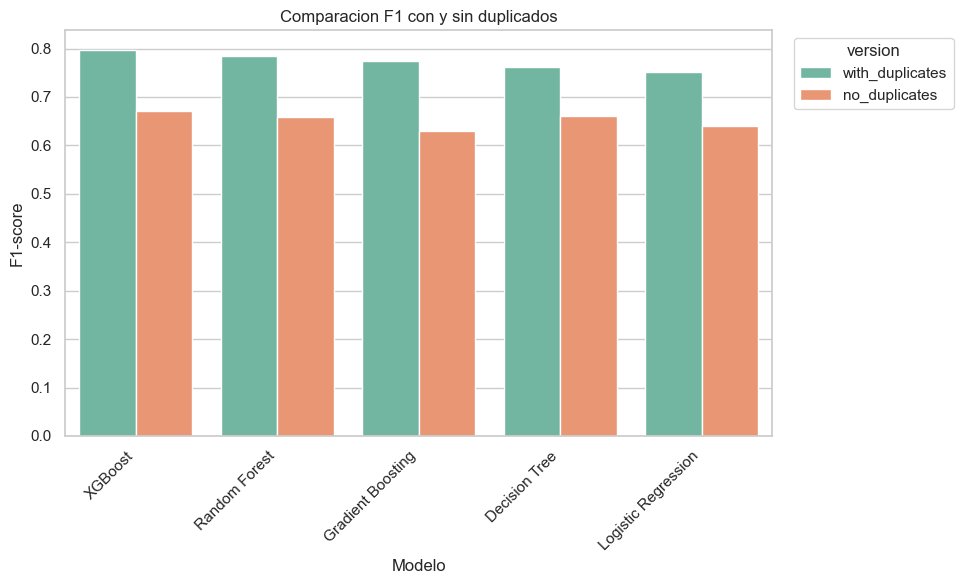

In [41]:
metric = "f1"
plot_df = results_df.copy()
plot_df[metric] = plot_df[metric].round(4)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=plot_df, x="modelo", y=metric, hue="version")
ax.set_title("Comparacion F1 con y sin duplicados")
ax.set_xlabel("Modelo")
ax.set_ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
ax.legend(title="version", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


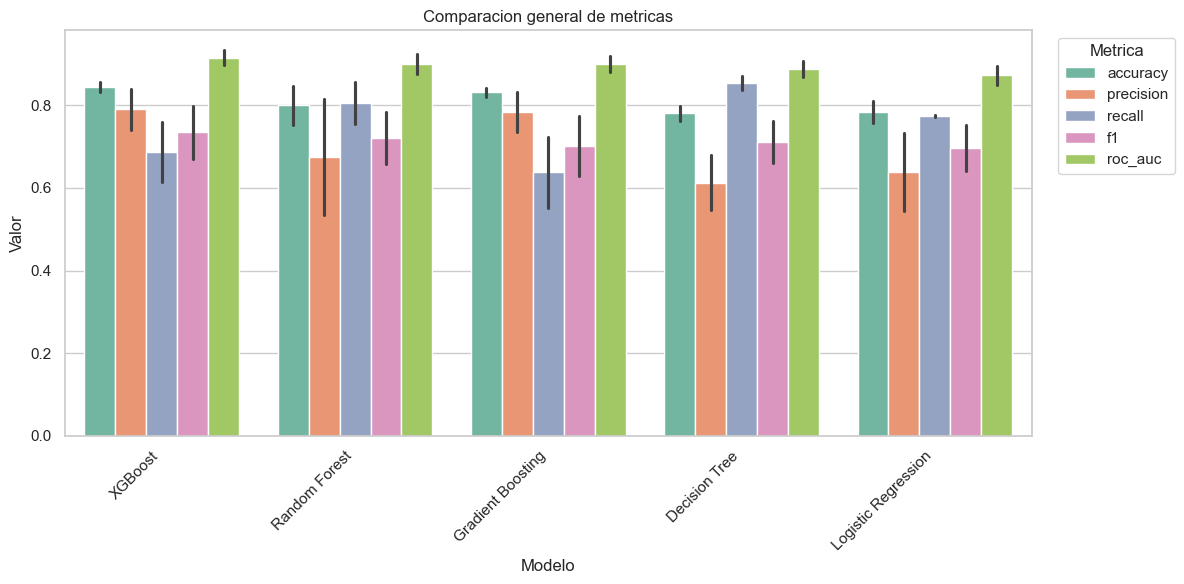

In [42]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
results_long = results_df.melt(id_vars=["version", "modelo"], value_vars=metrics_to_plot, var_name="metrica", value_name="valor")

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=results_long, x="modelo", y="valor", hue="metrica")
ax.set_title("Comparacion general de metricas")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 8. Mejor modelo global

Identifico el mejor modelo de la primera comparacion, antes de aplicar hiperparametrizacion. Este resultado sirve para decidir sobre que version del dataset y sobre que modelo merece la pena profundizar.


In [43]:
best_row = results_df.sort_values(["f1", "roc_auc"], ascending=False).iloc[0]
best_version = best_row["version"]
best_model_name = best_row["modelo"]
best_model = trained_models[(best_version, best_model_name)]
X_train, X_test, y_train, y_test = splits[best_version]
y_pred = best_model.predict(X_test)

print("Mejor version:", best_version)
print("Mejor modelo:", best_model_name)

print("Metricas:")
display(best_row.to_frame().T)

print("Classification report")
print(classification_report(y_test, y_pred))


Mejor version: with_duplicates
Mejor modelo: XGBoost
Metricas:


,version,modelo,accuracy,precision,recall,f1,roc_auc
4,with_duplicates,XGBoost,0.85645,0.839905,0.759479,0.79767,0.93376


Classification report
              precision    recall  f1-score   support

           0       0.86      0.91      0.89     14878
           1       0.84      0.76      0.80      8835

    accuracy                           0.86     23713
   macro avg       0.85      0.84      0.84     23713
weighted avg       0.86      0.86      0.85     23713



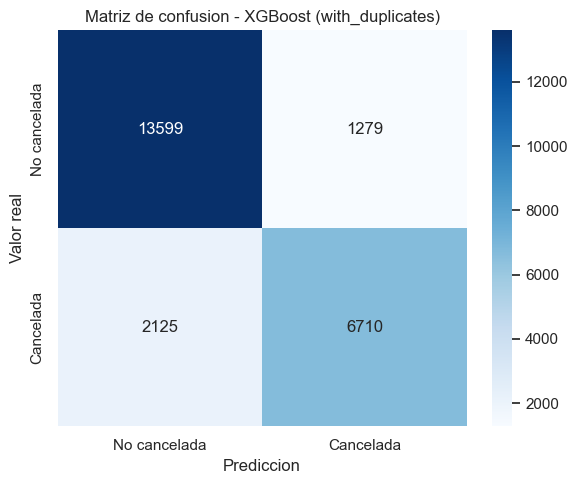

In [44]:
confusion_matrix_base = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    confusion_matrix_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No cancelada", "Cancelada"],
    yticklabels=["No cancelada", "Cancelada"],
)
ax.set_title(f"Matriz de confusion - {best_model_name} ({best_version})")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()


## 9. Decision sobre duplicados

Tras comparar los modelos entrenados con y sin duplicados, la version con duplicados obtiene mejores metricas.

En particular, XGBoost con duplicados supera claramente a XGBoost sin duplicados en `f1` y `roc_auc`. Ademas, el dataset no contiene un identificador unico de reserva (`booking_id`), por lo que no es posible asegurar que las filas repetidas sean errores de carga.

Por este motivo, la version seleccionada para profundizar y realizar la hiperparametrizacion es `with_duplicates`. Esta decision queda documentada como una limitacion del dataset y como una eleccion validada empiricamente.


## 10. Hiperparametrizacion de XGBoost

Como XGBoost es el modelo mas prometedor para datos tabulares y la version con duplicados obtiene mejores resultados, realizo la hiperparametrizacion sobre la version seleccionada: `with_duplicates`.

La busqueda se plantea en dos pasos:

1. Primero uso `RandomizedSearchCV` para explorar un espacio amplio de hiperparametros y encontrar una zona prometedora.
2. Despues uso `GridSearchCV` para hilar mas fino alrededor de los mejores valores encontrados en el paso anterior.

La metrica de optimizacion es `f1`, porque equilibra precision y recall para la clase de cancelacion.


In [45]:
xgb_version = "with_duplicates"
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = splits[xgb_version]

scale_pos_weight_base = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()
scale_pos_weight_values = [
    1,
    round(scale_pos_weight_base * 0.75, 2),
    round(scale_pos_weight_base, 2),
    round(scale_pos_weight_base * 1.25, 2),
    round(scale_pos_weight_base * 1.5, 2),
]
print("scale_pos_weight base:", round(scale_pos_weight_base, 2))

xgb_pipe = Pipeline(steps=[
    ("preprocessor", build_preprocessor(X_train_xgb)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

param_distributions = {
    "model__n_estimators": [200, 300, 500, 700, 1000],
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1, 0.15],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7, 10],
    "model__gamma": [0, 0.1, 0.2, 0.5, 1],
    "model__reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "model__reg_lambda": [0.5, 1, 2, 3, 5, 10],
    "model__scale_pos_weight": scale_pos_weight_values,
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_distributions,
    n_iter=60,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

xgb_search.fit(X_train_xgb, y_train_xgb)

print("Mejores parametros:")
print(xgb_search.best_params_)
print(f"Mejor F1 medio en validacion cruzada: {xgb_search.best_score_:.4f}")


scale_pos_weight base: 1.68
Mejores parametros:
{'model__subsample': 0.8, 'model__scale_pos_weight': np.float64(1.68), 'model__reg_lambda': 0.5, 'model__reg_alpha': 1, 'model__n_estimators': 700, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.15, 'model__gamma': 1, 'model__colsample_bytree': 0.6}
Mejor F1 medio en validacion cruzada: 0.8322


In [46]:
tuned_xgb_model = xgb_search.best_estimator_
y_pred_tuned = tuned_xgb_model.predict(X_test_xgb)
y_proba_tuned = tuned_xgb_model.predict_proba(X_test_xgb)[:, 1]

base_xgb_result = results_df[
    (results_df["version"] == xgb_version) &
    (results_df["modelo"] == "XGBoost")
].iloc[0].to_dict()

tuned_result = {
    "version": xgb_version,
    "modelo": "XGBoost tuned",
    "accuracy": accuracy_score(y_test_xgb, y_pred_tuned),
    "precision": precision_score(y_test_xgb, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test_xgb, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test_xgb, y_pred_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test_xgb, y_proba_tuned),
}

xgb_tuning_results = pd.DataFrame([
    base_xgb_result,
    tuned_result,
]).sort_values(["f1", "roc_auc"], ascending=False)

xgb_tuning_results.round(4)


,version,modelo,accuracy,precision,recall,f1,roc_auc
1,with_duplicates,XGBoost tuned,0.8768,0.8179,0.8611,0.8389,0.9519
0,with_duplicates,XGBoost,0.8565,0.8399,0.7595,0.7977,0.9338


### Busqueda fina con GridSearchCV

La primera busqueda con `RandomizedSearchCV` sirve para encontrar una zona prometedora de hiperparametros. Despues, uso `GridSearchCV` para probar combinaciones concretas dentro de un rango mas claro y controlado.

En vez de crear el grid automaticamente, defino los valores manualmente. Asi puedo ir ajustando el rango segun los resultados:

- si el mejor valor queda en el maximo del rango, en la siguiente prueba puedo subir ese rango;
- si el mejor valor queda en el minimo del rango, puedo probar valores mas bajos;
- si el mejor valor queda en el centro, probablemente esa zona ya esta razonablemente explorada.

Mantengo fijos el resto de parametros encontrados por `RandomizedSearchCV` para que el grid no se vuelva demasiado grande.


In [47]:
best_random_params = {
    key.replace("model__", ""): value
    for key, value in xgb_search.best_params_.items()
}

best_random_params_df = pd.DataFrame(
    best_random_params.items(),
    columns=["hiperparametro", "valor_random_search"],
).sort_values("hiperparametro")

display(best_random_params_df)

xgb_fine_pipe = Pipeline(steps=[
    ("preprocessor", build_preprocessor(X_train_xgb)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **best_random_params,
    )),
])

# Grid manual amplio.
# La idea es mover estos rangos segun donde caiga el mejor resultado.
fine_param_grid = {
    "model__n_estimators": [600, 650, 700, 750, 800],
    "model__max_depth": [9, 10, 11],
    "model__learning_rate": [0.10, 0.11, 0.12],
    "model__gamma": [0.2 , 0.3, 0.4],
}

# Si en otra iteracion quieres hacerlo todavia mas amplio, puedes anadir tambien:
# "model__subsample": [0.75, 0.8, 0.85, 0.9],
# "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9],
# pero esto multiplica mucho el tiempo de entrenamiento.

grid_summary = pd.DataFrame(
    [(key.replace("model__", ""), values) for key, values in fine_param_grid.items()],
    columns=["hiperparametro", "valores_probados"],
)
display(grid_summary)

total_combinations = int(np.prod([len(values) for values in fine_param_grid.values()]))
print("Total combinaciones GridSearchCV:", total_combinations)
print("Total entrenamientos con validacion cruzada:", total_combinations * cv.get_n_splits())

xgb_fine_search = GridSearchCV(
    estimator=xgb_fine_pipe,
    param_grid=fine_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    verbose=2,
)

xgb_fine_search.fit(X_train_xgb, y_train_xgb)

print("Mejores parametros busqueda fina con GridSearchCV:")
print(xgb_fine_search.best_params_)
print(f"Mejor F1 medio en validacion cruzada fina: {xgb_fine_search.best_score_:.4f}")


,hiperparametro,valor_random_search
9,colsample_bytree,0.60
8,gamma,1.00
7,learning_rate,0.15
6,max_depth,8.00
5,min_child_weight,5.00
4,n_estimators,700.00
3,reg_alpha,1.00
2,reg_lambda,0.50
1,scale_pos_weight,1.68
0,subsample,0.80


,hiperparametro,valores_probados
0,n_estimators,"[600, 650, 700, 750, 800]"
1,max_depth,"[9, 10, 11]"
2,learning_rate,"[0.1, 0.11, 0.12]"
3,gamma,"[0.2, 0.3, 0.4]"


Total combinaciones GridSearchCV: 135
Total entrenamientos con validacion cruzada: 405
Fitting 3 folds for each of 135 candidates, totalling 405 fits
[CV] END model__gamma=0.2, model__learning_rate=0.1, model__max_depth=9, model__n_estimators=600; total time=   5.4s
[CV] END model__gamma=0.2, model__learning_rate=0.1, model__max_depth=9, model__n_estimators=600; total time=   5.4s
[CV] END model__gamma=0.2, model__learning_rate=0.1, model__max_depth=9, model__n_estimators=600; total time=   5.2s
[CV] END model__gamma=0.2, model__learning_rate=0.1, model__max_depth=9, model__n_estimators=650; total time=   5.5s
[CV] END model__gamma=0.2, model__learning_rate=0.1, model__max_depth=9, model__n_estimators=650; total time=   5.8s
[CV] END model__gamma=0.2, model__learning_rate=0.1, model__max_depth=9, model__n_estimators=650; total time=   5.6s
[CV] END model__gamma=0.2, model__learning_rate=0.1, model__max_depth=9, model__n_estimators=700; total time=   6.3s
[CV] END model__gamma=0.2, mode

In [48]:
fine_tuned_xgb_model = xgb_fine_search.best_estimator_
y_pred_fine = fine_tuned_xgb_model.predict(X_test_xgb)
y_proba_fine = fine_tuned_xgb_model.predict_proba(X_test_xgb)[:, 1]

fine_tuned_result = {
    "version": xgb_version,
    "modelo": "XGBoost fine tuned",
    "accuracy": accuracy_score(y_test_xgb, y_pred_fine),
    "precision": precision_score(y_test_xgb, y_pred_fine, zero_division=0),
    "recall": recall_score(y_test_xgb, y_pred_fine, zero_division=0),
    "f1": f1_score(y_test_xgb, y_pred_fine, zero_division=0),
    "roc_auc": roc_auc_score(y_test_xgb, y_proba_fine),
}

# Reconstruyo la tabla desde cero para evitar duplicados si se reejecuta esta celda.
xgb_tuning_results = pd.DataFrame([
    base_xgb_result,
    tuned_result,
    fine_tuned_result,
]).sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)

xgb_tuning_results.round(4)


,version,modelo,accuracy,precision,recall,f1,roc_auc
0,with_duplicates,XGBoost fine tuned,0.8807,0.8295,0.8558,0.8425,0.9531
1,with_duplicates,XGBoost tuned,0.8768,0.8179,0.8611,0.8389,0.9519
2,with_duplicates,XGBoost,0.8565,0.8399,0.7595,0.7977,0.9338


### Mejores hiperparametros de XGBoost

Recojo en un dataframe la configuracion final del estimador XGBoost seleccionado. Incluyo tanto los parametros ajustados por el `GridSearchCV` como los parametros que se mantienen desde la busqueda anterior.

Esto facilita documentar el mejor modelo y preparar posteriormente el archivo `model_config.yaml`.


In [49]:
final_xgb_estimator = xgb_fine_search.best_estimator_.named_steps["model"]
final_xgb_params = final_xgb_estimator.get_params()

selected_xgb_params = [
    "objective",
    "n_estimators",
    "max_depth",
    "learning_rate",
    "subsample",
    "colsample_bytree",
    "min_child_weight",
    "gamma",
    "reg_alpha",
    "reg_lambda",
    "scale_pos_weight",
    "eval_metric",
    "tree_method",
    "random_state",
]

best_xgb_params_df = pd.DataFrame(
    [(param, final_xgb_params.get(param)) for param in selected_xgb_params],
    columns=["hiperparametro", "valor"],
)

best_xgb_params_df


,hiperparametro,valor
0,objective,binary:logistic
1,n_estimators,700
2,max_depth,10
3,learning_rate,0.11
4,subsample,0.8
5,colsample_bytree,0.6
6,min_child_weight,5
7,gamma,0.3
8,reg_alpha,1
9,reg_lambda,0.5


In [50]:
best_row = xgb_tuning_results.sort_values(["f1", "roc_auc"], ascending=False).iloc[0]

if best_row["modelo"] == "XGBoost fine tuned":
    best_version = xgb_version
    best_model_name = "XGBoost fine tuned"
    best_model = fine_tuned_xgb_model
    X_train, X_test, y_train, y_test = splits[best_version]
elif best_row["modelo"] == "XGBoost tuned":
    best_version = xgb_version
    best_model_name = "XGBoost tuned"
    best_model = tuned_xgb_model
    X_train, X_test, y_train, y_test = splits[best_version]
else:
    best_version = best_row["version"]
    best_model_name = best_row["modelo"]
    best_model = trained_models[(best_version, best_model_name)]
    X_train, X_test, y_train, y_test = splits[best_version]

y_pred = best_model.predict(X_test)

print("Mejor version final:", best_version)
print("Mejor modelo final:", best_model_name)

print("Metricas finales:")
display(best_row.to_frame().T)

print("Classification report final")
print(classification_report(y_test, y_pred))


Mejor version final: with_duplicates
Mejor modelo final: XGBoost fine tuned
Metricas finales:


,version,modelo,accuracy,precision,recall,f1,roc_auc
0,with_duplicates,XGBoost fine tuned,0.880741,0.829512,0.855801,0.842451,0.953052


Classification report final
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     14878
           1       0.83      0.86      0.84      8835

    accuracy                           0.88     23713
   macro avg       0.87      0.88      0.87     23713
weighted avg       0.88      0.88      0.88     23713



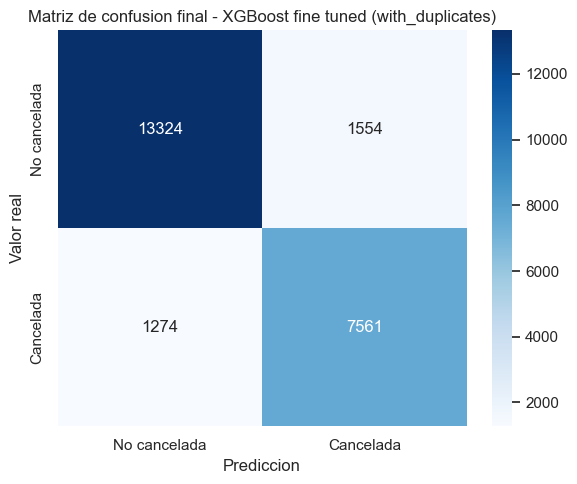

In [51]:
confusion_matrix_final = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    confusion_matrix_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No cancelada", "Cancelada"],
    yticklabels=["No cancelada", "Cancelada"],
)
ax.set_title(f"Matriz de confusion final - {best_model_name} ({best_version})")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()


## 11. Importancia de variables del modelo final

Una vez seleccionado el mejor modelo, reviso que variables han tenido mas peso en sus predicciones.

Como el modelo esta dentro de un `Pipeline`, primero se aplica el preprocesado: imputacion, escalado y One-Hot Encoding. Por eso, las variables categoricas se convierten en varias columnas internas. Para que sea mas facil de interpretar, agrupo esas columnas transformadas por su variable original.


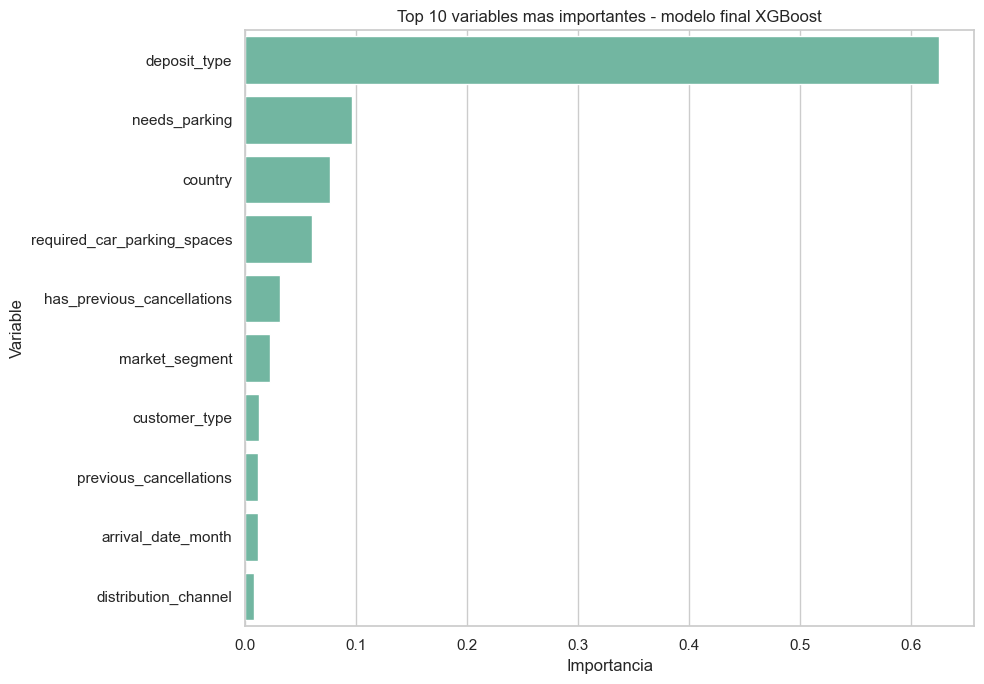

In [52]:
preprocessor = best_model.named_steps["preprocessor"]
xgb_model = best_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
feature_importance_df = pd.DataFrame({
    "feature_transformada": feature_names,
    "importancia": xgb_model.feature_importances_,
})

numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

def get_original_feature_name(feature_name):
    clean_name = feature_name.replace("num__", "").replace("cat__", "")

    if clean_name in numeric_features:
        return clean_name

    for column in sorted(categorical_features, key=len, reverse=True):
        if clean_name == column or clean_name.startswith(f"{column}_"):
            return column

    return clean_name

feature_importance_df["variable_original"] = feature_importance_df["feature_transformada"].apply(get_original_feature_name)

feature_importance_original = (
    feature_importance_df
    .groupby("variable_original", as_index=False)["importancia"]
    .sum()
    .sort_values("importancia", ascending=False)
)

top_features = feature_importance_original.head(10)

plt.figure(figsize=(10, 7))
ax = sns.barplot(data=top_features, x="importancia", y="variable_original")
ax.set_title("Top 10 variables mas importantes - modelo final XGBoost")
ax.set_xlabel("Importancia")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


## 12. Guardado de modelos

En este notebook guardo los archivos esperados en la carpeta `models`:

- `trained_model_1.pkl`: modelo entrenado intermedio. En este caso, XGBoost antes de la busqueda fina de hiperparametros.
- `final_model.pkl`: mejor modelo final tras la hiperparametrizacion de XGBoost.
- `model_config.yaml`: configuracion y metricas del modelo final.

De esta forma queda separada la primera version entrenada del modelo definitivo.


In [32]:
MODELS_DIR.mkdir(exist_ok=True)

trained_model_path = MODELS_DIR / "trained_model_1.pkl"
final_model_path = MODELS_DIR / "final_model.pkl"
config_path = MODELS_DIR / "model_config.yaml"

trained_model_1 = trained_models[(xgb_version, "XGBoost")]

with open(trained_model_path, "wb") as file:
    pickle.dump(trained_model_1, file)

with open(final_model_path, "wb") as file:
    pickle.dump(best_model, file)

final_estimator = best_model.named_steps["model"]
final_params = final_estimator.get_params()
selected_params = {
    "objective": final_params.get("objective"),
    "n_estimators": final_params.get("n_estimators"),
    "max_depth": final_params.get("max_depth"),
    "learning_rate": final_params.get("learning_rate"),
    "subsample": final_params.get("subsample"),
    "colsample_bytree": final_params.get("colsample_bytree"),
    "min_child_weight": final_params.get("min_child_weight"),
    "gamma": final_params.get("gamma"),
    "reg_alpha": final_params.get("reg_alpha"),
    "reg_lambda": final_params.get("reg_lambda"),
    "scale_pos_weight": final_params.get("scale_pos_weight"),
    "eval_metric": final_params.get("eval_metric"),
    "tree_method": final_params.get("tree_method"),
    "random_state": final_params.get("random_state"),
}

config_lines = [
    "project: Hotel Cancellation Prediction",
    f"target: {TARGET}",
    f"model_name: {best_model_name}",
    f"dataset_version: {best_version}",
    "duplicates_kept: true",
    "selection_metric: f1",
    "trained_model_file: models/trained_model_1.pkl",
    "model_file: models/final_model.pkl",
    "",
    "metrics:",
]

for metric_name in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    config_lines.append(f"  {metric_name}: {float(best_row[metric_name]):.6f}")

config_lines.extend(["", "hyperparameters:"])
for param_name, param_value in selected_params.items():
    if isinstance(param_value, str):
        config_lines.append(f'  {param_name}: "{param_value}"')
    else:
        config_lines.append(f"  {param_name}: {param_value}")

config_lines.extend([
    "",
    "notes:",
    "  - trained_model_1.pkl guarda el XGBoost inicial entrenado antes de la busqueda fina.",
    "  - final_model.pkl guarda el Pipeline final con preprocesado y XGBoost hiperparametrizado.",
    "  - Los duplicados exactos se mantienen porque no existe booking_id para confirmar que sean errores.",
])

config_path.write_text("\n".join(config_lines) + "\n", encoding="utf-8")

print(f"Modelo entrenado intermedio guardado en: {trained_model_path}")
print(f"Modelo final guardado en: {final_model_path}")
print(f"Configuracion guardada en: {config_path}")


Modelo entrenado intermedio guardado en: ..\models\trained_model_1.pkl
Modelo final guardado en: ..\models\final_model.pkl
Configuracion guardada en: ..\models\model_config.yaml


## 13. Conclusiones

- Se entrenan cinco modelos supervisados: Regresion Logistica, Decision Tree, Random Forest, Gradient Boosting y XGBoost.
- Se compara el rendimiento con duplicados y sin duplicados; la version con duplicados obtiene mejores resultados y se selecciona para el modelo final.
- Todos los modelos usan el mismo preprocesado mediante `Pipeline`, imputacion, escalado de numericas y One-Hot Encoding de categoricas.
- XGBoost es el modelo con mejor rendimiento global tras la hiperparametrizacion.
- El modelo final obtiene `accuracy=0.8807`, `precision=0.8295`, `recall=0.8558`, `f1=0.8425` y `roc_auc=0.9531` sobre test.
- Los hiperparametros finales principales son `n_estimators=700`, `max_depth=10`, `learning_rate=0.11` y `gamma=0.3`.
- La seleccion del modelo final se basa principalmente en `f1`, revisando tambien precision, recall y ROC-AUC.
- KMeans se usa como complemento no supervisado para segmentar reservas antes de la evaluacion supervisada, no como modelo predictivo principal.
- El modelo final se guarda en `models/final_model.pkl` y su configuracion en `models/model_config.yaml`.
